In [ ]:
!pip install tpot
from tpot import TPOTRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


data=pd.read_csv("/content/processed_rainfall_data.csv")
# data['datetime'] = pd.to_datetime(data['datetime'],format="%d-%m-%Y").apply(lambda x: x.timestamp()).astype(float)

# scaler = MinMaxScaler(feature_range=(0, 1))
# normalized_data = scaler.fit_transform(data)
# train,test = normalized_data[:int(0.9*len(normalized_data))],normalized_data[int(0.9*len(normalized_data)):]
# y_train=train[:,-2]
# train= np.delete(train, 1, axis=1)

# y_test=test[:,-2]
# test= np.delete(test, 1, axis=1)

train,test = data[:int(0.8*(len(data)))],data[int(0.8*(len(data))):]

y_train = train.pop("Precipitation")
y_train = pd.DataFrame(y_train)


y_test = test.pop("Precipitation")
y_test = pd.DataFrame(y_test)
# Create and configure the TPOTRegressor
tpot = TPOTRegressor(generations=6, population_size=20, random_state=42, verbosity=2)

# Fit TPOT to the training data
tpot.fit(train, y_train)

# Make predictions on the test data
y_pred = tpot.predict(test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE) and then RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Evaluate the best model on the test data
r2 = tpot.score(test, y_test)

r2_scr = r2_score(y_test, y_pred)

print("R-squared score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 score:",r2_scr)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 894.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stopit: filename=stopit-1.1.2-py3-none-any.whl size=11938 sha256=513d0ecccd82dcb218e04c977e0e383d60e06193a6e9ba31b6ff13509cbbe389
  Stored in directory: /root/.cache/pip/wheels/af/f9/87/bf5b3d565c2a007b4dae9d8142dccc85a9f164e517062dd519
Successfully built stopit
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Optimization Progress:   0%|          | 0/140 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: -108.123748179655

Generation 2 - Current best internal CV score: -107.31052617881221

Generation 3 - Current best internal CV score: -107.31052617881221

Generation 4 - Current best internal CV score: -107.31052617881221

Generation 5 - Current best internal CV score: -107.31052617881221

Generation 6 - Current best internal CV score: -107.31052617881221

Best pipeline: RandomForestRegressor(input_matrix, bootstrap=True, max_features=0.7500000000000001, min_samples_leaf=9, min_samples_split=9, n_estimators=100)
R-squared score: -70.22618994148462
Mean Absolute Error (MAE): 3.8073478457241605
Root Mean Squared Error (RMSE): 8.380106797737403
R2 score: 0.37049681444776206


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


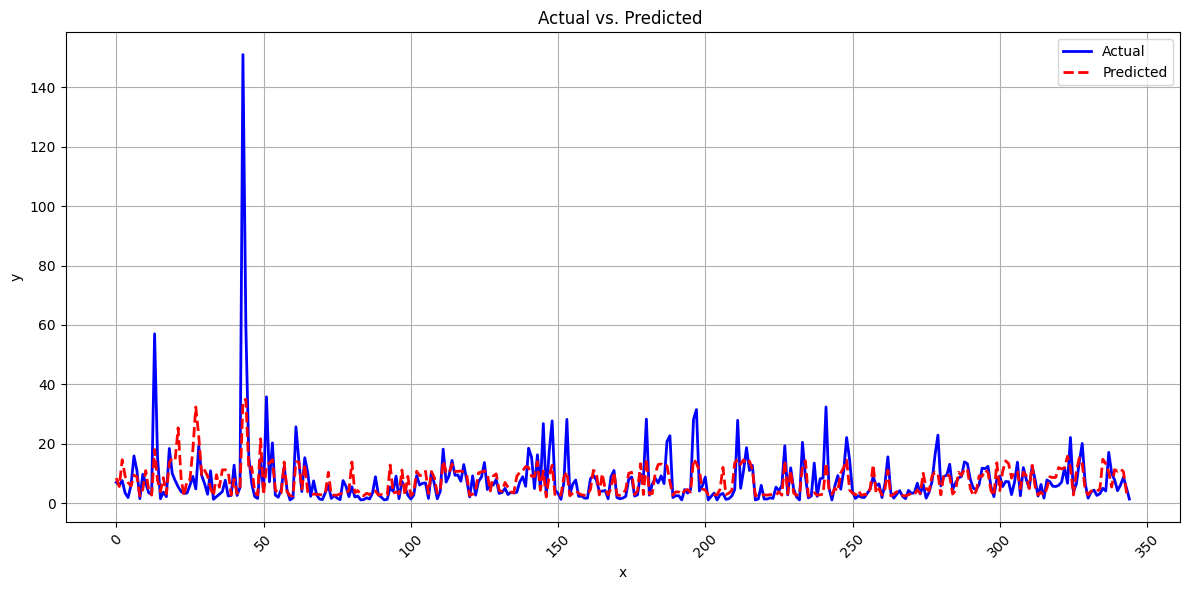

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot( np.array(y_test), label='Actual', color='blue', linewidth=2)

plt.plot(y_pred, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Actual vs. Predicted ')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
!pip install tensorflow==2.8.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 92.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.3/462.3 kB 41.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 88.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 54.9 MB/s eta 0:00:00
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.15.0
    Uninstalling tensorflow-estimator-2.15.0:
      Successfully uninstalled tensorflow-estimator-2.15.0
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
  Attempting uninstall: tensorboard-data-server
    Found existing instal

In [ ]:
!pip install autokeras==1.1.0
!pip install tensorflow==2.8.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 736.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.9 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement tensorflow==2.8.1 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.8.1


In [ ]:
import autokeras as ak
import numpy as np
import pandas as pd
import keras


# Load the training and validation datasets
# Load the dataset
dataset = pd.read_csv("/content/processed_rainfall_data.csv")
# dataset['datetime'] = pd.to_datetime(dataset['datetime'],format="%d-%m-%Y").apply(lambda x: x.timestamp()).astype(float)

# Split the data into training and validation sets
train,test = dataset[:int(0.8*(len(dataset)))],dataset[int(0.8*(len(dataset))):]

y_train = train.pop("Precipitation")
y_train = pd.DataFrame(y_train)


y_test = test.pop("Precipitation")
y_test = pd.DataFrame(y_test)

X_train, X_test = train,test
y_train, y_test = y_train,y_test



clf=ak.StructuredDataRegressor(

    loss="mean_squared_error",
    metrics=None,
    project_name="structured_data_regressor",
    max_trials=10,
    objective="val_loss"
)




# Train the model on the training dataset
clf.fit( x=X_train, y=y_train, epochs=200, callbacks=None, validation_split=0.1, validation_data=(X_test, y_test),batch_size=1)




# Make predictions on the validation dataset
train_loss = clf.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = clf.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


train_predictions = clf.predict(X_train)
test_predictions =clf.predict(X_test)
train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')


Trial 10 Complete [00h 00m 59s]
val_loss: 16051630.0

Best val_loss So Far: 125.00492858886719
Total elapsed time: 00h 26m 22s
Epoch 1/200
1377/1377 [==============================] - 4s 2ms/step - loss: 9221.6230 - mean_squared_error: 9221.6230 - val_loss: 3043.2881 - val_mean_squared_error: 3043.2881
Epoch 2/200
1377/1377 [==============================] - 3s 2ms/step - loss: 7141.1255 - mean_squared_error: 7141.1255 - val_loss: 2503.0232 - val_mean_squared_error: 2503.0232
Epoch 3/200
1377/1377 [==============================] - 3s 2ms/step - loss: 5974.6611 - mean_squared_error: 5974.6611 - val_loss: 1581.1272 - val_mean_squared_error: 1581.1272
Epoch 4/200
1377/1377 [==============================] - 3s 2ms/step - loss: 5764.8081 - mean_squared_error: 5764.8081 - val_loss: 1572.7395 - val_mean_squared_error: 1572.7395
Epoch 5/200
1377/1377 [==============================] - 4s 3ms/step - loss: 5209.6006 - mean_squared_error: 5209.6006 - val_loss: 956.4412 - val_mean_squared_error:

In [ ]:
y_test = np.array(y_test)
y_test = y_test.reshape(-1)

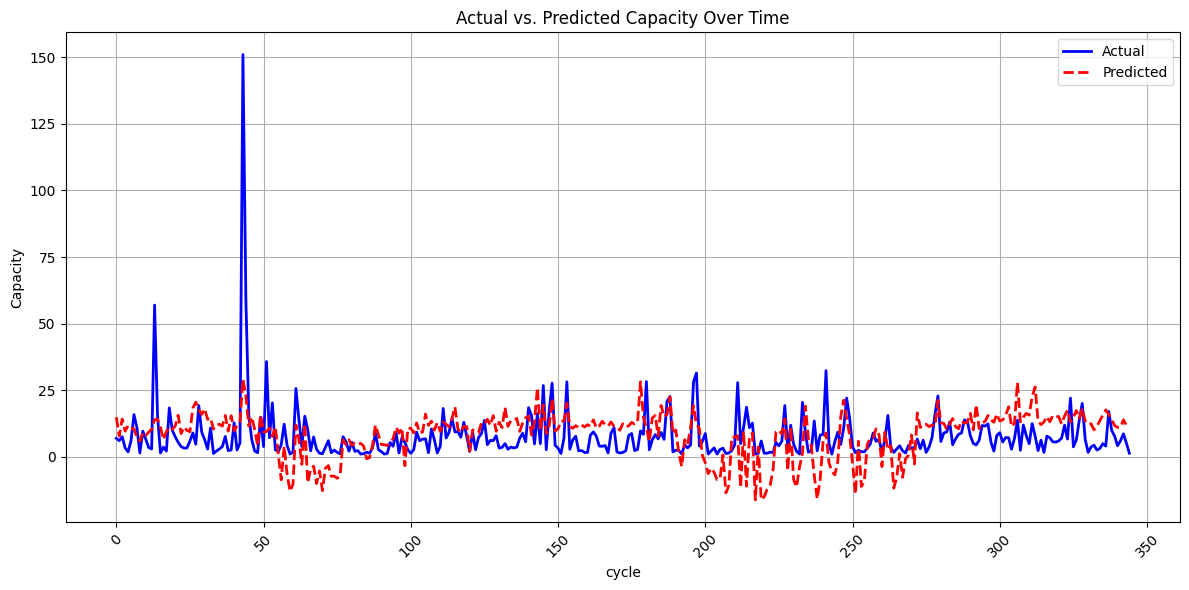

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

# Plot the actual "close" values
plt.plot( y_test, label='Actual', color='blue', linewidth=2)

# print(time_axis)
# print(y_pred)
# Plot the predicted "close" values
plt.plot(test_rul_predictions, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('cycle')
plt.ylabel('Capacity')
plt.title('Actual vs. Predicted Capacity Over Time')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
!pip install h2o

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.3/265.3 MB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for h2o: filename=h2o-3.46.0.3-py2.py3-none-any.whl size=265365897 sha256=7dcfe6f10c2a23f2a9179c1fa7e483f62490e78df783ec7da15dda1782dc7d51
  Stored in directory: /root/.cache/pip/wheels/c4/63/41/baa115b5255e1db3e2383bce4e2e6181746aac0b42264c242f
Successfully built h2o


In [ ]:
import h2o
from h2o.automl import H2OAutoML
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

# Initialize H2O cluster

h2o.init()
# Load your dataset
data =h2o.import_file(f"/content/processed_rainfall_data.csv")
target = "Precipitation"


# Split the data into training and testing sets
train, test = data.split_frame(ratios=[0.9])

# Define the predictor columns (features)
predictors = [col for col in data.columns if col != target]

# Train the AutoML model
aml = H2OAutoML(max_runtime_secs=3600)  # You can adjust the maximum runtime
aml.train(x=predictors, y=target, training_frame=train)

# Get the leader model
leader = aml.leader

# Make predictions on the test data
y_predictions = leader.predict(test)

# Evaluate model performance
performance = leader.model_performance(test)

# Calculate the requested metrics
rmse = performance.rmse()
mae = performance.mae()
mse = performance.mse()
r2 = performance.r2()

# Print the performance metrics
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")

# Shutdown H2O cluster
h2o.cluster().shutdown()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.23" 2024-04-16; OpenJDK Runtime Environment (build 11.0.23+9-post-Ubuntu-1ubuntu122.04.1); OpenJDK 64-Bit Server VM (build 11.0.23+9-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.10/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpka1wuflf
  JVM stdout: /tmp/tmpka1wuflf/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpka1wuflf/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.3
H2O_cluster_version_age:,15 days
H2O_cluster_name:,H2O_from_python_unknownUser_3ivuiy
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Root Mean Squared Error (RMSE): 7.766320427186281
Mean Absolute Error (MAE): 5.003643106831769
Mean Squared Error (MSE): 60.3157329777309
R-squared (R^2): 0.4051875863644758
H2O session _sid_a9a7 closed.


In [ ]:
import pandas as pd

df = pd.read_csv("/content/new_rainfall_data.csv")

df.keys()

Index(['Unnamed: 0', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'Dew', 'humidity', 'Precipitation',
       'precipcover', 'windspeed', 'winddir', 'cloudcover', 'solarenergy',
       'uvindex', 'moonphase', 'icon_cloudy', 'icon_partly-cloudy-day',
       'icon_rain', 'icon_snow'],
      dtype='object')

<Axes: xlabel='Precipitation', ylabel='Count'>

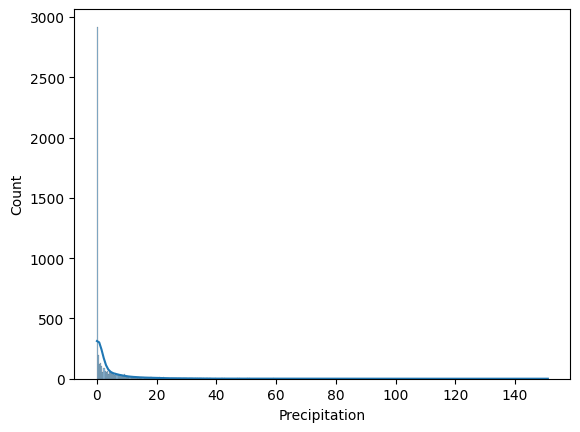

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df['Precipitation'], kde=True)

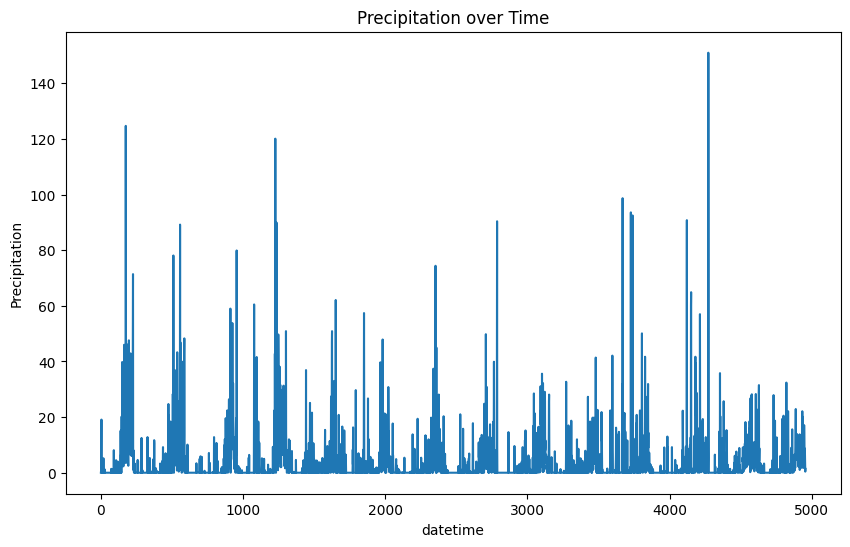

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot( df['Precipitation'])
plt.xlabel('datetime')
plt.ylabel('Precipitation')
plt.title('Precipitation over Time')
plt.show()

In [ ]:
df1= pd.DataFrame()
list1 = []
list2 = []
for i in range(len(df)):
  if df["Precipitation"][i] >1.0:
    for j in df.columns:
      if j=="Unnamed: 0":
        continue
      list2.append(df[j][i])
    list1.append(list2)
    list2 = []
a=df.columns
a=a[1:]
df1 = pd.DataFrame(list1,columns=a)
df1.to_csv("more_processed_rainfall_data.csv")

In [ ]:
df1

,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,Dew,humidity,Precipitation,...,windspeed,winddir,cloudcover,solarenergy,uvindex,moonphase,icon_cloudy,icon_partly-cloudy-day,icon_rain,icon_snow
0,08-02-2010,9.3,3.3,6.5,7.6,0.1,4.6,3.8,83.3,11.3,...,13.0,89.9,98.5,4.3,2,0.80,False,False,True,False
1,09-02-2010,9.9,0.3,4.5,7.2,-3.3,1.9,2.6,88.5,19.1,...,20.5,123.7,64.5,12.6,5,0.84,False,False,True,False
2,12-02-2010,11.1,2.4,6.3,11.1,0.0,5.4,-2.3,55.3,1.5,...,10.4,4.2,39.7,14.4,6,0.94,False,False,True,False
3,23-02-2010,12.7,3.2,7.6,12.7,1.0,7.1,2.3,70.2,5.2,...,14.8,176.2,72.5,12.4,6,0.31,False,False,True,False
4,04-03-2010,19.4,6.1,11.6,19.4,4.3,10.8,0.1,49.0,1.2,...,16.2,281.4,18.0,20.9,8,0.62,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1717,26-08-2023,19.2,10.6,14.4,19.2,10.6,14.4,10.6,79.2,4.2,...,13.0,219.4,28.2,25.4,10,0.34,False,False,True,False
1718,27-08-2023,18.6,10.2,13.9,18.6,10.2,13.9,10.4,80.1,6.1,...,13.0,212.3,19.1,26.7,10,0.37,False,False,True,False
1719,28-08-2023,17.6,10.1,13.4,17.6,10.1,13.4,10.4,82.4,8.7,...,12.6,212.4,16.9,26.6,10,0.40,False,False,True,False
1720,29-08-2023,18.3,9.7,13.6,18.3,9.7,13.6,9.7,77.7,5.2,...,12.6,220.3,6.1,26.6,10,0.44,False,False,True,False


In [ ]:
!pip install arch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

for k in df.columns:
  if k == "datetime" or k=="Unnamed: 0":
    continue
  print(k)
  returns_df = df[k]
  # Fit a GARCH(1,1) model
  model = arch_model(returns_df, vol='EGarch',  p=1, q=1,power=1.0, dist='StudentsT')
  garch_fit = model.fit()

  # Print the model summary
  print(garch_fit.summary())

  # Plot the conditional volatility
  garch_vol = garch_fit.conditional_volatility
  plt.figure(figsize=(12, 6))
  plt.plot(garch_vol)
  plt.title('Conditional Volatility from EGARCH(1,1) Model')
  plt.show()

/usr/local/lib/python3.10/dist-packages/arch/univariate/base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.048e+06. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.01 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

<Axes: >

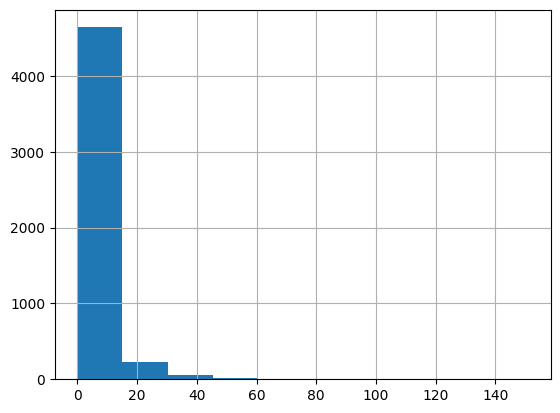

In [ ]:
df["Precipitation"].hist()

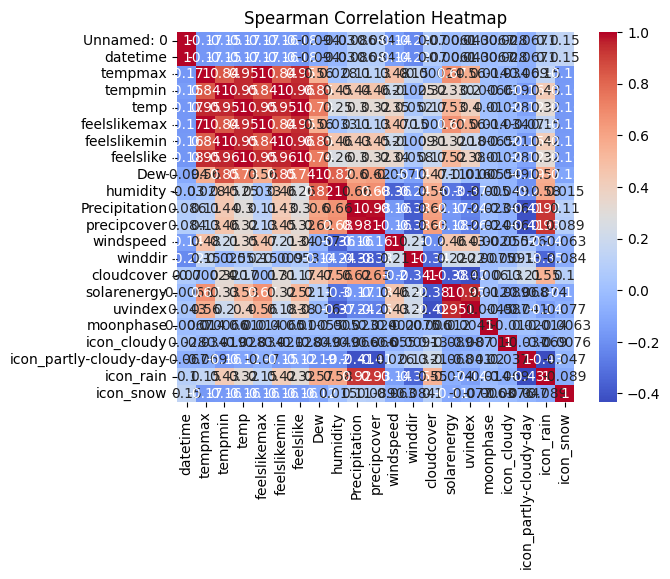

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a random correlation matrix
df = pd.read_csv("/content/new_rainfall_data.csv")
df['datetime'] = pd.to_datetime(df['datetime'],format="%d-%m-%Y").apply(lambda x: x.timestamp()).astype(float)

corr_matrix = df.corr(method='spearman')

# Create a DataFrame from the correlation matrix
df = pd.DataFrame(corr_matrix, columns=['datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax','feelslikemin', 'feelslike', 'Dew', 'humidity', 'Precipitation','precipcover', 'windspeed', 'winddir', 'cloudcover', 'solarenergy','uvindex', 'moonphase', 'icon_cloudy', 'icon_partly-cloudy-day','icon_rain', 'icon_snow'])

# Create the heatmap
sns.heatmap(df, cmap="coolwarm", annot=True)
plt.title("Spearman Correlation Heatmap")
plt.show()


In [ ]:
corr_matrix

,Unnamed: 0,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,Dew,humidity,...,windspeed,winddir,cloudcover,solarenergy,uvindex,moonphase,icon_cloudy,icon_partly-cloudy-day,icon_rain,icon_snow
Unnamed: 0,1.000000,1.000000,-0.174108,-0.150824,-0.171411,-0.172095,-0.164819,-0.176644,-0.094018,-0.030035,...,-0.141773,-0.222164,0.070497,-0.006093,0.043080,-0.006710,0.028280,-0.066952,0.101073,0.148699
datetime,1.000000,1.000000,-0.174108,-0.150824,-0.171411,-0.172095,-0.164819,-0.176644,-0.094018,-0.030035,...,-0.141773,-0.222164,0.070497,-0.006093,0.043080,-0.006710,0.028280,-0.066952,0.101073,0.148699
tempmax,-0.174108,-0.174108,1.000000,0.841865,0.949845,0.999730,0.837172,0.946668,0.555278,0.028028,...,0.475825,0.153071,-0.000245,0.671157,0.558912,0.013647,-0.033566,-0.068905,0.151184,-0.165283
tempmin,-0.150824,-0.150824,0.841865,1.000000,0.954440,0.844108,0.998025,0.957752,0.851666,0.452757,...,0.210750,-0.024941,0.317651,0.333070,0.195056,0.006579,-0.019279,-0.155715,0.427114,-0.158603
temp,-0.171411,-0.171411,0.949845,0.954440,1.000000,0.950497,0.950506,0.999333,0.731785,0.250427,...,0.351015,0.051774,0.171617,0.532366,0.395861,0.010188,-0.027595,-0.122551,0.315559,-0.163874
feelslikemax,-0.172095,-0.172095,0.999730,0.844108,0.950497,1.000000,0.839413,0.947568,0.559195,0.032787,...,0.473589,0.152017,0.001695,0.669727,0.557105,0.013846,-0.033515,-0.069763,0.154052,-0.164561
feelslikemin,-0.164819,-0.164819,0.837172,0.998025,0.950506,0.839413,1.000000,0.955566,0.851511,0.457158,...,0.210277,-0.009042,0.310863,0.320473,0.182672,0.006503,-0.021405,-0.150794,0.415456,-0.158284
feelslike,-0.176644,-0.176644,0.946668,0.957752,0.999333,0.947568,0.955566,1.000000,0.739234,0.261513,...,0.344407,0.058274,0.174266,0.521504,0.384623,0.010093,-0.028212,-0.120934,0.315512,-0.163441
Dew,-0.094018,-0.094018,0.555278,0.851666,0.731785,0.559195,0.851511,0.739234,1.000000,0.817146,...,-0.056548,-0.135056,0.467353,0.105440,-0.015568,0.005499,-0.048826,-0.192955,0.565850,-0.115389
humidity,-0.030035,-0.030035,0.028028,0.452757,0.250427,0.032787,0.457158,0.261513,0.817146,1.000000,...,-0.358004,-0.238684,0.564479,-0.297254,-0.366810,-0.004987,-0.048763,-0.196758,0.580957,0.014818


In [ ]:
data['datetime'] = pd.to_datetime(data['datetime'],format="%d-%m-%Y").apply(lambda x: x.timestamp()).astype(float)
corr,_ = pearsonr(data["Precipitation"],data["datetime"])
print(f"datetime : {corr}")


datetime : -0.034912985001790714


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr


data=pd.read_csv("/content/new_rainfall_data.csv")
for k in data.columns:
  if k == "datetime":
    continue
  corr,_ = pearsonr(data["Precipitation"],data[k])
  print(f"{k} : {corr}")



Unnamed: 0 : -0.03491298500179072
tempmax : -0.004897602361844411
tempmin : 0.25293621797405125
temp : 0.15151803678790512
feelslikemax : 0.0012577311482282892
feelslikemin : 0.2404272474973977
feelslike : 0.15196707649765032
Dew : 0.38668410854215474
humidity : 0.4522281270292379
Precipitation : 1.0
precipcover : 0.6485776884123573
windspeed : -0.08720503476726761
winddir : -0.1621695839525409
cloudcover : 0.4254581163949316
solarenergy : -0.25382436176304685
uvindex : -0.33346349510975193
moonphase : -0.02290371344543175
icon_cloudy : -0.030359259566601373
icon_partly-cloudy-day : -0.18955625967174325
icon_rain : 0.4216203796716522
icon_snow : 0.047675187978653395


icon_rain,cloudcover,precipcover,humidity,dew,tempmin,feelslike,feelslikemin,temp


In [ ]:
df = pd.DataFrame(columns=['icon_rain','cloudcover','precipcover','humidity','dew','tempmin','feelslikemin',"solarenergy",'temp',"uvindex","icon_partly-cloudy-day",'Precipitation'])
df

,icon_rain,cloudcover,precipcover,humidity,dew,tempmin,feelslikemin,solarenergy,temp,uvindex,icon_partly-cloudy-day,Precipitation


In [ ]:
df["icon_rain"] = data["icon_rain"]
df["cloudcover"] = data["cloudcover"]
df["precipcover"] = data["precipcover"]
df["humidity"] = data["humidity"]
df["dew"] = data["Dew"]
df["tempmin"] = data["tempmin"]
df["feelslikemin"] = data["feelslikemin"]
df["temp"] = data["temp"]
df["Precipitation"] = data["Precipitation"]
df["solarenergy"] = data["solarenergy"]
df["uvindex"] = data["uvindex"]
df["icon_partly-cloudy-day"] = data["icon_partly-cloudy-day"]
df

,icon_rain,cloudcover,precipcover,humidity,dew,tempmin,feelslikemin,solarenergy,temp,uvindex,icon_partly-cloudy-day,Precipitation
0,False,6.2,0.00,29.9,-4.83,1.6,-0.7,18.2,7.8,8,False,0.0
1,False,48.4,0.00,41.5,-4.70,3.7,1.9,14.7,8.7,7,True,0.0
2,False,67.6,0.00,56.8,0.50,4.6,3.0,11.1,9.0,6,True,0.0
3,True,98.5,62.50,83.3,3.80,3.3,0.1,4.3,6.5,2,False,11.3
4,True,64.5,100.00,88.5,2.60,0.3,-3.3,12.6,4.5,5,False,19.1
...,...,...,...,...,...,...,...,...,...,...,...,...
4952,True,16.9,62.50,82.4,10.40,10.1,10.1,26.6,13.4,10,False,8.7
4953,True,6.1,50.00,77.7,9.70,9.7,9.7,26.6,13.6,10,False,5.2
4954,True,4.5,16.67,67.3,8.70,10.2,10.2,26.4,15.1,10,False,0.4
4955,True,14.5,12.50,72.2,10.60,11.8,11.8,23.8,15.9,9,False,0.4


In [ ]:
df.to_csv("real_rainfall.csv")

In [ ]:
prediction_length=1
context_length=12
batch_size=32
epochs = 200
from transformers import InformerConfig, InformerModel,InformerForPrediction,AutoformerForPrediction,AutoformerConfig
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [ ]:
df = pd.read_csv("/content/processed_rainfall_data.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,Dew,humidity,Precipitation,precipcover,windspeed,winddir,cloudcover,solarenergy,uvindex,moonphase,icon_rain,icon_snow
0,0,0,9.3,3.3,6.5,7.6,0.1,4.6,3.8,83.3,11.3,62.50,13.0,89.9,98.5,4.3,2,0.80,True,False
1,1,1,9.9,0.3,4.5,7.2,-3.3,1.9,2.6,88.5,19.1,100.00,20.5,123.7,64.5,12.6,5,0.84,True,False
2,2,2,11.1,2.4,6.3,11.1,0.0,5.4,-2.3,55.3,1.5,33.33,10.4,4.2,39.7,14.4,6,0.94,True,False
3,3,3,12.7,3.2,7.6,12.7,1.0,7.1,2.3,70.2,5.2,58.33,14.8,176.2,72.5,12.4,6,0.31,True,False
4,4,4,19.4,6.1,11.6,19.4,4.3,10.8,0.1,49.0,1.2,29.17,16.2,281.4,18.0,20.9,8,0.62,True,False


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
df["datetime"] = pd.to_datetime(df["datetime"],format="%d-%m-%Y")

KeyError: 'datetime'

In [ ]:
def preprocess_data(df):
  df["datetime"] = pd.to_datetime(df["datetime"])
  df["year"] = df["datetime"].dt.year
  df["month"] = df["datetime"].dt.month
  df["day"] = df["datetime"].dt.day
  df["weekday"] = df["datetime"].dt.weekday

  return df


In [ ]:
# df = preprocess_data(df)
train , test = train_test_split(df, test_size=0.2,shuffle=False)
# train , test = df,df1

In [ ]:
df.to_csv("processed_data.csv")

In [ ]:
test

,Unnamed: 0.1,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,Dew,humidity,Precipitation,precipcover,windspeed,winddir,cloudcover,solarenergy,uvindex,moonphase,icon_rain,icon_snow
1377,1377,1377,22.5,17.7,20.3,22.5,17.7,20.3,18.2,88.5,7.0,91.67,14.4,163.6,69.0,13.6,5,0.70,True,False
1378,1378,1378,24.6,18.5,21.1,24.6,18.5,21.1,19.0,88.9,6.1,70.83,15.8,205.1,87.4,19.5,8,0.80,True,False
1379,1379,1379,25.5,18.9,21.5,25.5,18.9,21.5,18.9,86.4,7.6,100.00,14.4,194.3,81.9,21.6,9,0.83,True,False
1380,1380,1380,23.6,18.5,20.6,23.6,18.5,20.6,19.0,91.1,3.4,83.33,14.8,207.1,81.3,14.0,6,0.86,True,False
1381,1381,1381,23.6,17.5,20.3,23.6,17.5,20.3,18.6,90.3,1.9,79.17,17.3,219.4,77.7,13.3,6,0.96,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1717,1717,1717,19.2,10.6,14.4,19.2,10.6,14.4,10.6,79.2,4.2,70.83,13.0,219.4,28.2,25.4,10,0.34,True,False
1718,1718,1718,18.6,10.2,13.9,18.6,10.2,13.9,10.4,80.1,6.1,70.83,13.0,212.3,19.1,26.7,10,0.37,True,False
1719,1719,1719,17.6,10.1,13.4,17.6,10.1,13.4,10.4,82.4,8.7,62.50,12.6,212.4,16.9,26.6,10,0.40,True,False
1720,1720,1720,18.3,9.7,13.6,18.3,9.7,13.6,9.7,77.7,5.2,50.00,12.6,220.3,6.1,26.6,10,0.44,True,False


In [ ]:
class InformerDataset(Dataset):
  def __init__(self, df, context_length):
    self.target = df["Precipitation"].values
    self.features = df.drop(["Precipitation","Unnamed: 0","Unnamed: 0.1"], axis=1).values
    self.context_length = context_length
  def __len__(self):
    return len(self.target)-self.context_length
  def __getitem__(self,idx):
    x = self.target[idx:idx+self.context_length]
    x = torch.tensor(np.asarray(x,dtype=np.float32),dtype=torch.float32).to(device)
    xt = self.features[idx:idx+self.context_length]
    xt = torch.tensor(np.asarray(xt,dtype=np.float32),dtype=torch.float32).to(device)
    y = self.target[idx+self.context_length]
    y = torch.tensor(np.asarray(y,dtype=np.float32),dtype=torch.float32).to(device)
    yt = self.features[idx+self.context_length]
    yt = torch.tensor(np.asarray(yt,dtype=np.float32),dtype=torch.float32).to(device)

    return x,xt,y,yt


In [ ]:
train_dataset = InformerDataset(train, 19)
test_dataset = InformerDataset(test,19)

In [ ]:
len(train_dataset)

1358

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
configuration = AutoformerConfig(prediction_length=1,context_length=context_length,num_time_features=17,lags_sequence=[1, 2, 3, 4, 5, 6, 7])

model = AutoformerForPrediction(configuration).to(device)
configuration = model.config

In [ ]:
configuration.context_length + max(configuration.lags_sequence)

19

In [ ]:
optmizer = optim.Adam(model.parameters(),lr=1e-4)
criterion = nn.MSELoss()
model_name = "Informer.pt"

In [ ]:
model.train()
loss_hitory = []
val_loss_history = []
for epoch in range(epochs):
  total_loss =0.0
  for batch in train_loader:
    x,xt,y,yt = batch
    mask = torch.ones_like(x)
    y = y.unsqueeze(-1)
    yt = yt.view(yt.shape[0],1,yt.shape[1])
    outputs = model(past_values=x,past_time_features=xt,past_observed_mask=mask,future_values=y,future_time_features=yt)
    loss = outputs.loss
    loss.backward()
    optmizer.step()
    total_loss += loss.item()
    optmizer.zero_grad()
  loss_hitory.append(total_loss/len(train_loader))
  print(f"Epoch {epoch+1}/{epochs}, train Loss: {loss_hitory[-1]}")

  with torch.no_grad():
    model.eval()
    val_loss = 0.0
    for batch in test_loader:
      x,xt,y,yt = batch
      mask = torch.ones_like(x)
      y = y.unsqueeze(-1)
      yt = yt.view(yt.shape[0],1,yt.shape[1])
      outputs = model(past_values=x,past_time_features=xt,past_observed_mask=mask,future_values=y,future_time_features=yt)
      val_loss += outputs.loss.item()

    val_loss_history.append(val_loss/len(test_loader))
    print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {val_loss_history[-1]}")
    if val_loss_history[-1] <= min(val_loss_history):
      torch.save(model.state_dict(),model_name)
      print("Model saved")
    model.state_dict(torch.load(model_name))
    model.train()



Epoch 1/200, train Loss: 10.328380130058111
Epoch 1/200, Validation Loss: 7.636711554093794
Model saved


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1898: UserWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


Epoch 2/200, train Loss: 6.760318046392396
Epoch 2/200, Validation Loss: 5.387429757551714
Model saved
Epoch 3/200, train Loss: 4.922157387400782
Epoch 3/200, Validation Loss: 4.4321043491363525
Model saved
Epoch 4/200, train Loss: 4.511427230613176
Epoch 4/200, Validation Loss: 4.320841637524691
Model saved
Epoch 5/200, train Loss: 4.456502398779226
Epoch 5/200, Validation Loss: 4.231838031248613
Model saved
Epoch 6/200, train Loss: 4.331630457279294
Epoch 6/200, Validation Loss: 4.102128484032371
Model saved
Epoch 7/200, train Loss: 4.211279918981153
Epoch 7/200, Validation Loss: 3.9622684825550425
Model saved
Epoch 8/200, train Loss: 4.0136854315913
Epoch 8/200, Validation Loss: 3.8595383817499336
Model saved
Epoch 9/200, train Loss: 3.8773966223694556
Epoch 9/200, Validation Loss: 3.7904857288707388
Model saved
Epoch 10/200, train Loss: 3.8076966917792032
Epoch 10/200, Validation Loss: 3.6788840727372603
Model saved
Epoch 11/200, train Loss: 3.757432033849317
Epoch 11/200, Validati

In [ ]:
predictions = []

for batch in test_loader:
    x,xt,y,yt = batch
    mask = torch.ones_like(x)
    y = y.unsqueeze(-1)
    yt = yt.view(yt.shape[0],1,yt.shape[1])
    outputs = model.generate(past_values=x,past_time_features=xt,past_observed_mask=mask,future_time_features=yt)
    mean_prediction = outputs.sequences.mean(dim=1)
    predictions.extend(mean_prediction)


In [ ]:
true_values = test["Precipitation"].values
true_values = true_values[-len(predictions):]

In [ ]:
predictions = torch.cat(predictions, dim=0)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
predictions=predictions.cpu().numpy().reshape(-1)
rmse = np.sqrt(mean_squared_error(true_values, predictions))
mae = mean_absolute_error(true_values, predictions)
test_r2 = r2_score(true_values, predictions)
print(f"r2 score : {test_r2}")
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')

r2 score : 0.1676317231560439
Root Mean Squared Error (RMSE): 9.530961097076485
Mean Absolute Error (MAE): 4.000747626946748


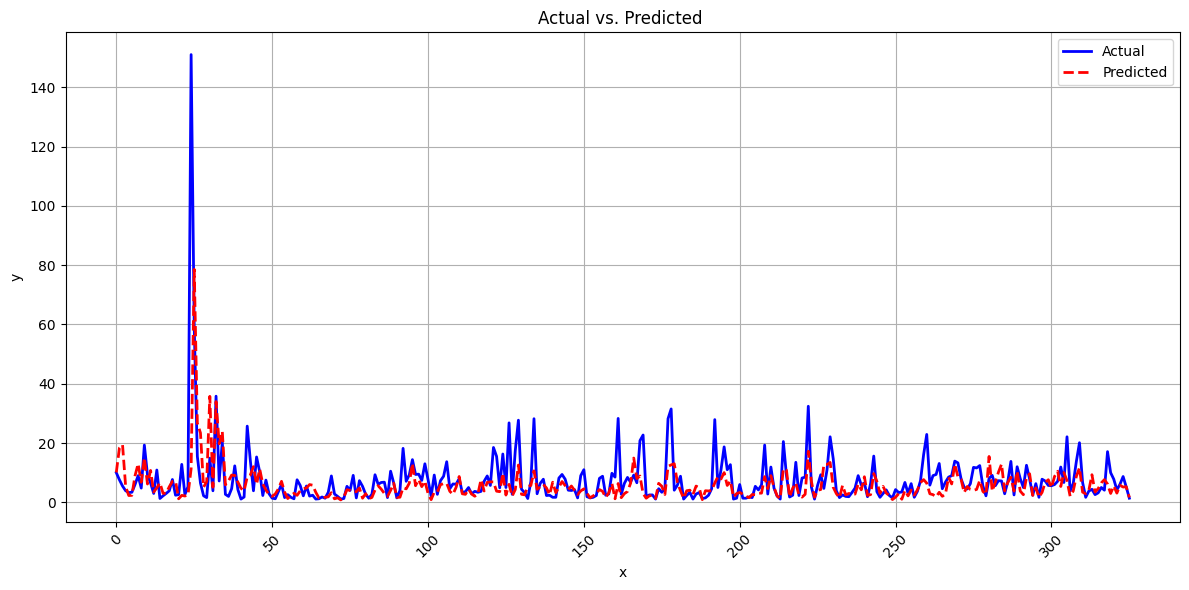

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot( true_values, label='Actual', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Actual vs. Predicted ')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()


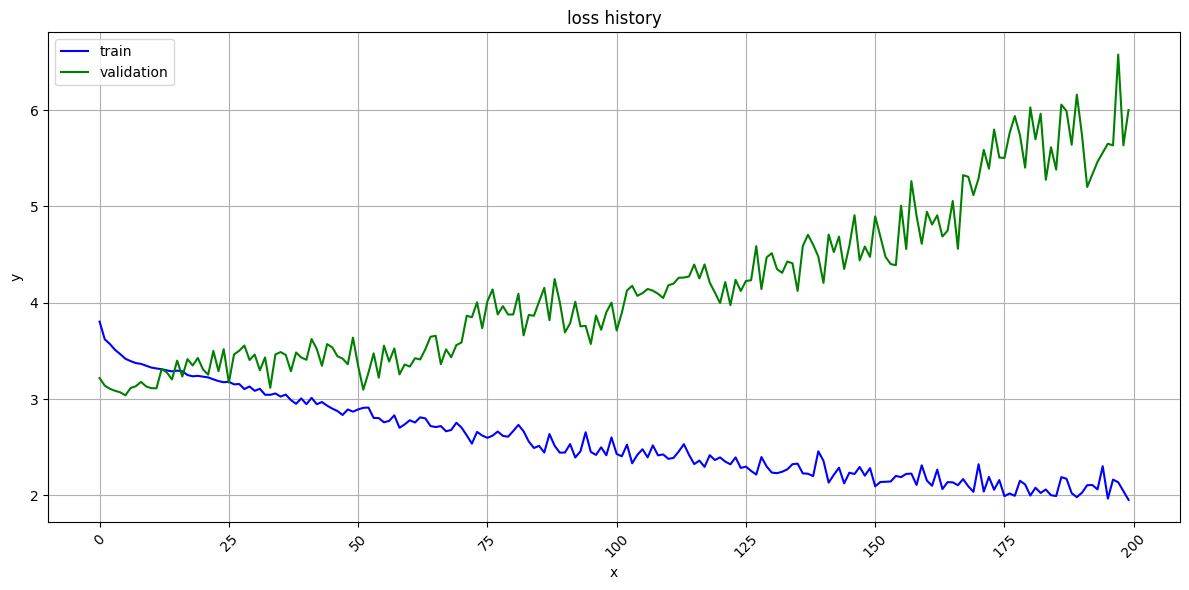

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot( loss_hitory, label='train', color='blue')
plt.plot(val_loss_history, label='validation', color='green')

# Set axis labels and a title
plt.xlabel('x')
plt.ylabel('y')
plt.title('loss history')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()


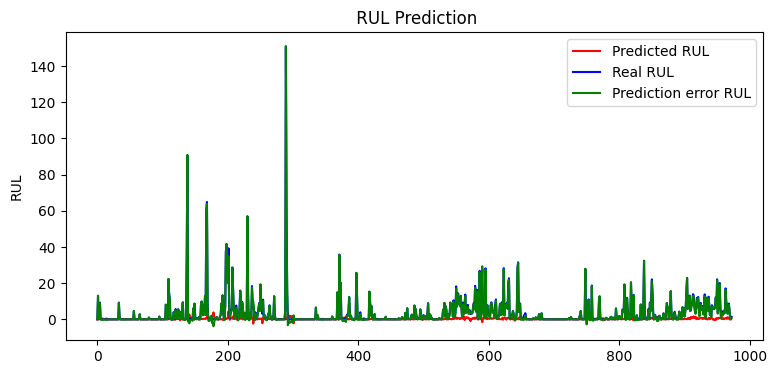

In [ ]:

plt.rcParams["figure.figsize"] = (9,4)
plt.plot(predictions,color='red',label='Predicted RUL')
plt.plot(true_values,color='blue',label='Real RUL')
plt.plot(true_values-predictions,color='green',label='Prediction error RUL')
plt.title(' RUL Prediction')
# plt.xlabel('capacity')
# plt.ylim(0,2)
plt.ylabel('RUL')
plt.legend()
plt.show()